In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path("./neyman_runs")  # root containing many exp_* folders
THRESHOLDS = [49, 98]  # vertical budget lines

methods = ["neyman_standard", "neyman_limited"]

# discover runs
run_dirs = sorted([p for p in ROOT.glob("exp_*/run_*") if p.is_dir()])
if not run_dirs:
    raise RuntimeError(f"No runs under {ROOT}")

print(f"Found {len(run_dirs)} runs")

# load baselines
baselines = []
for rd in run_dirs:
    bpath = rd / "baseline_exact.npy"
    if bpath.exists():
        base = np.load(bpath).astype(np.float32).reshape(-1)
        # keep only explainable positions, drop NaNs from exact baseline
        base = base[np.isfinite(base)]
        baselines.append(base)
if not baselines:
    raise RuntimeError("No baseline_exact.npy found.")
n_expl = min(len(b) for b in baselines)
baselines = np.stack([b[:n_expl] for b in baselines], axis=0)
baseline_mean = baselines.mean(axis=0)  # vector-level average baseline

print("Explainable tokens used:", n_expl)

# load trajectory views
vecs: dict[str, dict[int, list[np.ndarray]]] = {m: {} for m in methods}
phase_by_run_method: list[tuple[str, str, int]] = []  # (run_id, method, first_neyman_num_masks)

for rd in run_dirs:
    run_id = rd.name
    for m in methods:
        tcsv = rd / m / "trajectory.csv"
        if not tcsv.exists():
            continue
        dfm = pd.read_csv(tcsv)
        # record phase-change for this run+method
        NEYMAN = "neyman"
        neyman_rows = dfm[dfm["stage"] == NEYMAN].sort_values("num_masks")
        if not neyman_rows.empty:
            phase_by_run_method.append((run_id, m, int(neyman_rows.iloc[0]["num_masks"])))
        # collect vectors
        for _, row in dfm.iterrows():
            nm = int(row["num_masks"])
            npy = rd / m / row["path"]
            v = np.load(npy)
            v = v[:n_expl]
            vecs[m].setdefault(nm, []).append(v)

# build mean vectors
mean_vecs: dict[str, dict[int, np.ndarray]] = {m: {} for m in methods}
for m in methods:
    for nm, lst in vecs[m].items():
        arr = np.stack(lst, axis=0)  # (runs_k, n_expl)
        mean_vecs[m][nm] = arr.mean(axis=0)

# metrics on mean vectors


def metric_on_vectors(a: np.ndarray, b: np.ndarray):
    """Calculate metric on vectors."""
    a = torch.from_numpy(a).float()
    b = torch.from_numpy(b).float()
    eps = 1e-8
    valid = torch.isfinite(a) & torch.isfinite(b)
    av = a[valid]
    bv = b[valid]
    out = {}
    out["mae"] = float((av - bv).abs().mean())
    out["rel_l2"] = float((av - bv).norm() / (bv.norm().item() + eps))
    denom = (av.norm() * bv.norm()).item()
    out["cosine"] = float(torch.dot(av, bv) / (denom + eps)) if denom > 0 else float("nan")
    av0, bv0 = av - av.mean(), bv - bv.mean()
    denom_p = (av0.norm() * bv0.norm()).item()
    out["pearson"] = float(torch.dot(av0, bv0) / (denom_p + eps)) if denom_p > 0 else float("nan")
    # stabilized rMAE%
    out["rmae_pct"] = float(100.0 * ((av - bv).abs() / torch.clamp(bv.abs(), min=eps)).mean())
    return out


agg_rows = []
for m in methods:
    for nm, vmean in mean_vecs[m].items():
        stats = metric_on_vectors(vmean, baseline_mean)
        stats.update({"method": m, "num_masks": int(nm)})
        agg_rows.append(stats)

df_mean_metrics = pd.DataFrame(agg_rows).sort_values(["method", "num_masks"]).reset_index(drop=True)
df_mean_metrics.head()

Found 11 runs
Explainable tokens used: 7


,mae,rel_l2,cosine,pearson,rmae_pct,method,num_masks
0,0.737165,3.339333,0.585508,0.133146,1.428572e+09,neyman_limited,2
1,0.697392,3.148647,0.605874,0.200572,1.233767e+09,neyman_limited,4
2,0.537135,2.387589,0.692662,0.472302,8.532562e+08,neyman_limited,6
3,0.459016,2.046237,0.740704,0.610437,7.683142e+08,neyman_limited,8
4,0.364472,1.646018,0.808306,0.775145,6.498742e+08,neyman_limited,10


In [ ]:
# phase change summary
phase_df = pd.DataFrame(phase_by_run_method, columns=["run_id", "method", "num_masks"])
phase_stats = phase_df.groupby("method")["num_masks"].agg(["count", "mean", "std", "min", "max"]).reset_index()
phase_stats  # pylint: disable=pointless-statement

,method,count,mean,std,min,max
0,neyman_limited,11,64.000000,3.098387,60,68
1,neyman_standard,11,102.545455,11.665022,86,126


In [ ]:
per_run_rows = []
for rd in run_dirs:
    for m in methods:
        f = rd / m / "metrics_vs_exact.csv"
        if not f.exists():
            continue
        df = pd.read_csv(f)
        df = df[["num_masks", "mae", "rmae_pct", "cosine", "pearson", "rel_l2"]].copy()
        df["run_id"] = rd.name
        df["method"] = m
        per_run_rows.append(df)
df_runs_metrics = pd.concat(per_run_rows, ignore_index=True)


def ci_df(metric: str) -> pd.DataFrame:
    """Compute 95% CI for a given metric."""
    g = (
        df_runs_metrics.groupby(["method", "num_masks"], as_index=False)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    g["sem"] = g["std"] / np.sqrt(g["count"].clip(lower=1))
    g["lo95"] = g["mean"] - 1.96 * g["sem"]
    g["hi95"] = g["mean"] + 1.96 * g["sem"]
    return g


ci = {m: ci_df(m) for m in ["mae", "rmae_pct", "cosine", "pearson", "rel_l2"]}

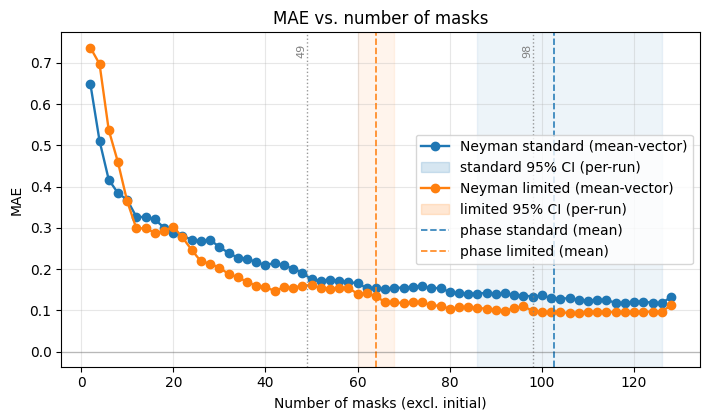

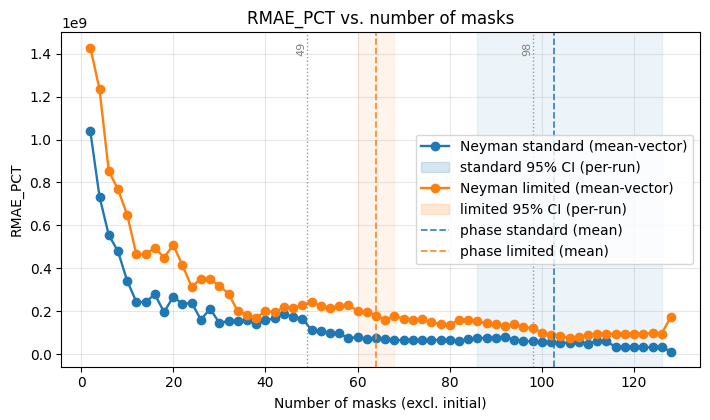

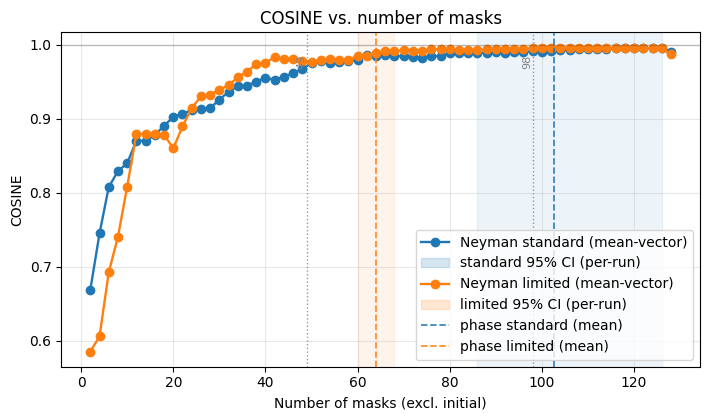

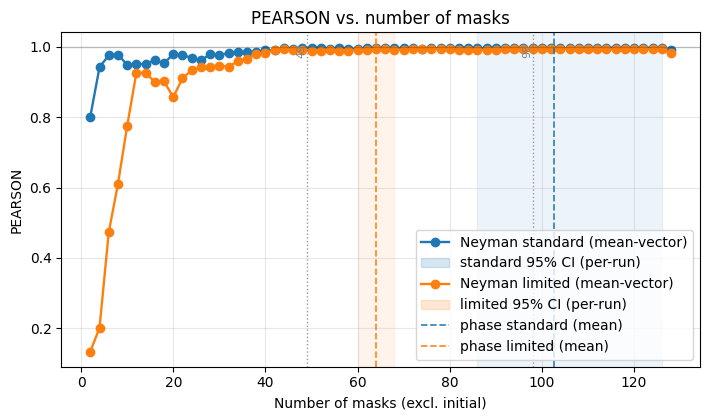

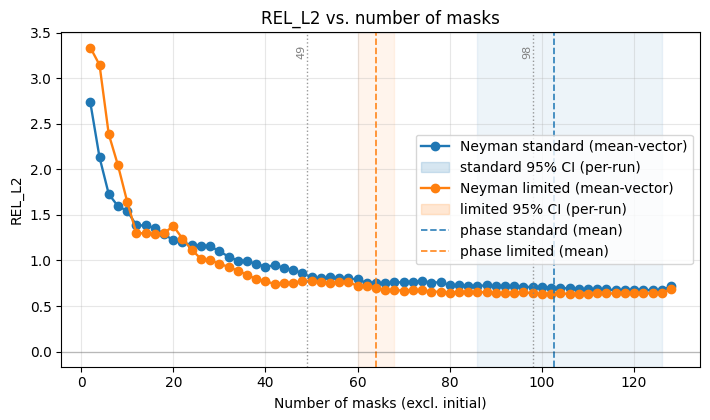

In [ ]:
# plotting
PAPER_FIGSIZE = (7.2, 4.3)


def plot_metric(metric: str, thresholds=None):
    """Plot a give metric vs. number of masks."""
    thresholds = thresholds or []
    _, ax = plt.subplots(figsize=PAPER_FIGSIZE)

    # mean-vector metrics
    for meth, color in zip(methods, ["tab:blue", "tab:orange"]):
        sub = df_mean_metrics[df_mean_metrics["method"] == meth].sort_values("num_masks")
        ax.plot(
            sub["num_masks"],
            sub[metric],
            marker="o",
            linewidth=1.7,
            label=f"{meth.replace('neyman_', 'Neyman ')} (mean-vector)",
        )

        # CI shading from per-run metrics
        if metric in ci:
            csub = ci[metric][ci[metric]["method"] == meth].sort_values("num_masks")
            if not csub.empty:
                ax.fill_between(
                    csub["num_masks"],
                    csub["lo95"],
                    csub["hi95"],
                    alpha=0.18,
                    color=color,
                    label=f"{meth.replace('neyman_', '')} 95% CI (per-run)",
                )

    # phase-change mean+band
    for meth, color in zip(methods, ["tab:blue", "tab:orange"]):
        r = phase_stats[phase_stats["method"] == meth]
        if not r.empty:
            mu = r["mean"].values[0]
            xmin = r["min"].values[0]
            xmax = r["max"].values[0]
            ax.axvline(
                mu,
                linestyle="--",
                linewidth=1.25,
                color=color,
                alpha=0.9,
                label=f"{meth.replace('neyman_', 'phase ')} (mean)",
            )
            ax.axvspan(xmin, xmax, color=color, alpha=0.08)

    # thresholds
    for t in thresholds:
        ax.axvline(t, color="gray", linestyle=":", linewidth=1.0, alpha=0.8)
        ax.text(t, ax.get_ylim()[1] * 0.97, f"{t}", rotation=90, va="top", ha="right", fontsize=8, color="gray")

    if metric in ("cosine", "pearson"):
        ax.axhline(1.0, color="k", alpha=0.2, linewidth=1.0)
    if metric in ("mae", "rel_l2"):
        ax.axhline(0.0, color="k", alpha=0.2, linewidth=1.0)

    ax.set_title(f"{metric.upper()} vs. number of masks")
    ax.set_xlabel("Number of masks (excl. initial)")
    ax.set_ylabel(metric.upper())
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


for m in ["mae", "rmae_pct", "cosine", "pearson", "rel_l2"]:
    plot_metric(m, thresholds=THRESHOLDS)